# Optimization Algorithms - Implementation Assignment

**Objective:** Implement gradient-based optimizers from scratch and compare their performance.

**Skills tested:**
- Understanding of optimizer mechanics
- NumPy proficiency
- Debugging convergence issues
- Hyperparameter tuning

**Instructions:**
- Complete each function marked with `TODO`
- Do NOT use PyTorch/TensorFlow optimizer implementations
- Test your implementations on the provided problems
- Compare convergence behavior across optimizers

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional

np.random.seed(42)

---

## Problem 1: Vanilla Gradient Descent (10 points)

Implement standard batch gradient descent.

**Formula:**
```
θ = θ - η * ∇L(θ)
```

where:
- `θ` = parameters
- `η` = learning rate
- `∇L(θ)` = gradient of loss w.r.t. parameters

In [40]:
class GradientDescent:
    def __init__(self, learning_rate: float = 0.01):
        """
        Initialize Gradient Descent optimizer.
        
        Args:
            learning_rate: Step size for parameter updates
        """
        self.lr = learning_rate
    
    def step(self, params: np.ndarray, grads: np.ndarray) -> np.ndarray:
        """
        Perform one optimization step.
        
        Args:
            params: Current parameters (shape: [d])
            grads: Gradients w.r.t. parameters (shape: [d])
        
        Returns:
            Updated parameters (shape: [d])
        """
        # TODO: Implement gradient descent update
        # Hint: One line of code
        params -= self.lr * grads
        
        return params

---

## Problem 2: SGD with Momentum (15 points)

Implement SGD with momentum.

**Formula:**
```
v = β * v + ∇L(θ)
θ = θ - η * v
```

where:
- `v` = velocity (exponential moving average of gradients)
- `β` = momentum coefficient (typically 0.9)

In [41]:
class SGDMomentum:
    def __init__(self, learning_rate: float = 0.01, beta: float = 0.9):
        """
        Initialize SGD with Momentum optimizer.
        
        Args:
            learning_rate: Step size for parameter updates
            beta: Momentum coefficient (decay rate for velocity)
        """
        self.lr = learning_rate
        self.beta = beta
        self.v = None  # Velocity, initialized on first step
    
    def step(self, params: np.ndarray, grads: np.ndarray) -> np.ndarray:
        """
        Perform one optimization step with momentum.
        
        Args:
            params: Current parameters (shape: [d])
            grads: Gradients w.r.t. parameters (shape: [d])
        
        Returns:
            Updated parameters (shape: [d])
        """
        # TODO: Initialize velocity if this is the first step
        # Hint: Use np.zeros_like(params)
        if self.v is None:
            self.v = np.zeros_like(params)
        
        # TODO: Update velocity using momentum formula
        self.v = self.beta * self.v + grads
        
        # TODO: Update parameters using velocity
        params -= self.lr * self.v
        
        return params

---

## Problem 3: RMSProp (20 points)

Implement RMSProp (Root Mean Square Propagation).

**Formula:**
```
E[g²] = β * E[g²] + (1 - β) * g²
θ = θ - (η / √(E[g²] + ε)) * g
```

where:
- `E[g²]` = exponential moving average of squared gradients
- `β` = decay rate (typically 0.9)
- `ε` = small constant for numerical stability (1e-8)
- `g` = current gradient

In [42]:
class RMSProp:
    def __init__(self, learning_rate: float = 0.001, beta: float = 0.9, epsilon: float = 1e-8):
        """
        Initialize RMSProp optimizer.
        
        Args:
            learning_rate: Step size for parameter updates
            beta: Decay rate for moving average of squared gradients
            epsilon: Small constant for numerical stability
        """
        self.lr = learning_rate
        self.beta = beta
        self.epsilon = epsilon
        self.E_g_sq = None  # Moving average of squared gradients
    
    def step(self, params: np.ndarray, grads: np.ndarray) -> np.ndarray:
        """
        Perform one optimization step with RMSProp.
        
        Args:
            params: Current parameters (shape: [d])
            grads: Gradients w.r.t. parameters (shape: [d])
        
        Returns:
            Updated parameters (shape: [d])
        """
        # TODO: Initialize E[g²] if this is the first step
        if self.E_g_sq is None:
            self.E_g_sq = np.zeros_like(params)
        
        # TODO: Update moving average of squared gradients
        # self.E_g_sq = ...
        self.E_g_sq = self.beta * self.E_g_sq + (1 - self.beta) * (grads**2)
        
        # TODO: Compute adaptive learning rate and update parameters
        params -= (self.lr / (np.sqrt(self.E_g_sq) + self.epsilon)) * grads
        
        return params

---

## Problem 4: Adam (25 points)

Implement Adam (Adaptive Moment Estimation).

**Formula:**
```
m = β₁ * m + (1 - β₁) * g          # First moment (momentum)
v = β₂ * v + (1 - β₂) * g²         # Second moment (RMSProp)

m̂ = m / (1 - β₁ᵗ)                  # Bias correction
v̂ = v / (1 - β₂ᵗ)

θ = θ - η * m̂ / (√v̂ + ε)
```

where:
- `m` = first moment estimate (momentum)
- `v` = second moment estimate (squared gradients)
- `t` = timestep
- Default: `β₁ = 0.9`, `β₂ = 0.999`, `ε = 1e-8`

In [43]:
class Adam:
    def __init__(self, learning_rate: float = 0.001, beta1: float = 0.9, 
                 beta2: float = 0.999, epsilon: float = 1e-8):
        """
        Initialize Adam optimizer.
        
        Args:
            learning_rate: Step size for parameter updates
            beta1: Decay rate for first moment (momentum)
            beta2: Decay rate for second moment (squared gradients)
            epsilon: Small constant for numerical stability
        """
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None  # First moment
        self.v = None  # Second moment
        self.t = 0     # Timestep
    
    def step(self, params: np.ndarray, grads: np.ndarray) -> np.ndarray:
        """
        Perform one optimization step with Adam.
        
        Args:
            params: Current parameters (shape: [d])
            grads: Gradients w.r.t. parameters (shape: [d])
        
        Returns:
            Updated parameters (shape: [d])
        """
        # TODO: Initialize m and v if this is the first step
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        
        # TODO: Increment timestep
        self.t += 1
        
        # TODO: Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        
        # TODO: Update biased second moment estimate
        self.v = self.beta2 * self.v + (1-self.beta2) * (grads**2)
        
        # TODO: Compute bias-corrected first moment estimate
        m_hat = self.m / (1 - self.beta1**self.t)
        
        # TODO: Compute bias-corrected second moment estimate
        v_hat = self.v / (1 - self.beta2**self.t)
        
        # TODO: Update parameters
        params -= (self.lr / (np.sqrt(v_hat) + self.epsilon)) * m_hat
        
        return params

---

## Problem 5: AdamW (30 points)

Implement AdamW (Adam with decoupled weight decay).

**Key difference from Adam:** Weight decay is applied directly to parameters, NOT to gradients.

**Formula:**
```
m = β₁ * m + (1 - β₁) * g
v = β₂ * v + (1 - β₂) * g²

m̂ = m / (1 - β₁ᵗ)
v̂ = v / (1 - β₂ᵗ)

θ = θ - η * (m̂ / (√v̂ + ε) + λ * θ)    # Note: λ * θ is weight decay
```

where:
- `λ` = weight decay coefficient (typically 0.01)

In [44]:
class AdamW:
    def __init__(self, learning_rate: float = 0.001, beta1: float = 0.9, 
                 beta2: float = 0.999, epsilon: float = 1e-8, weight_decay: float = 0.01):
        """
        Initialize AdamW optimizer.
        
        Args:
            learning_rate: Step size for parameter updates
            beta1: Decay rate for first moment (momentum)
            beta2: Decay rate for second moment (squared gradients)
            epsilon: Small constant for numerical stability
            weight_decay: Weight decay coefficient (L2 regularization strength)
        """
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.weight_decay = weight_decay
        self.m = None
        self.v = None
        self.t = 0
    
    def step(self, params: np.ndarray, grads: np.ndarray) -> np.ndarray:
        """
        Perform one optimization step with AdamW.
        
        Args:
            params: Current parameters (shape: [d])
            grads: Gradients w.r.t. parameters (shape: [d])
        
        Returns:
            Updated parameters (shape: [d])
        """
        # TODO: Initialize m and v if this is the first step
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        
        # TODO: Increment timestep
        self.t += 1
        
        # TODO: Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        
        # TODO: Update biased second moment estimate
        self.v = self.beta2 * self.v + (1-self.beta2) * (grads**2)
        
        # TODO: Compute bias-corrected first moment estimate
        m_hat = self.m / (1 - self.beta1**self.t)
        
        # TODO: Compute bias-corrected second moment estimate
        v_hat = self.v / (1 - self.beta2**self.t)
        
        # TODO: Update parameters
        params -= self.lr * (m_hat / (np.sqrt(v_hat) + self.epsilon) + self.weight_decay * params)
        
        return params

---

## Test Problem 1: Quadratic Function (Simple)

Minimize `f(x, y) = x² + y²`

- **Gradient:** `∇f = [2x, 2y]`
- **Global minimum:** `(0, 0)`
- **Initial point:** `(5, 5)`

In [45]:
def quadratic_loss(params: np.ndarray) -> float:
    """f(x, y) = x² + y²"""
    return np.sum(params ** 2)

def quadratic_grad(params: np.ndarray) -> np.ndarray:
    """∇f = [2x, 2y]"""
    return 2 * params

# Test your optimizers
def test_optimizer_quadratic(optimizer_class, optimizer_name: str, **kwargs):
    """
    Test an optimizer on the quadratic function.
    
    Args:
        optimizer_class: Optimizer class to test
        optimizer_name: Name for plotting
        **kwargs: Arguments to pass to optimizer
    """
    params = np.array([5.0, 5.0])
    optimizer = optimizer_class(**kwargs)
    
    losses = []
    trajectory = [params.copy()]
    
    for step in range(100):
        loss = quadratic_loss(params)
        losses.append(loss)
        
        grads = quadratic_grad(params)
        params = optimizer.step(params, grads)
        trajectory.append(params.copy())
    
    trajectory = np.array(trajectory)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    ax1.plot(losses)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{optimizer_name} - Loss Curve')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    
    # Trajectory
    x = np.linspace(-6, 6, 100)
    y = np.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2
    
    ax2.contour(X, Y, Z, levels=20, alpha=0.5)
    ax2.plot(trajectory[:, 0], trajectory[:, 1], 'r.-', linewidth=2, markersize=4)
    ax2.plot(0, 0, 'g*', markersize=20, label='Minimum')
    ax2.plot(trajectory[0, 0], trajectory[0, 1], 'bo', markersize=10, label='Start')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title(f'{optimizer_name} - Trajectory')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"{optimizer_name} - Final loss: {losses[-1]:.6f}")
    print(f"Final params: [{params[0]:.6f}, {params[1]:.6f}]\n")

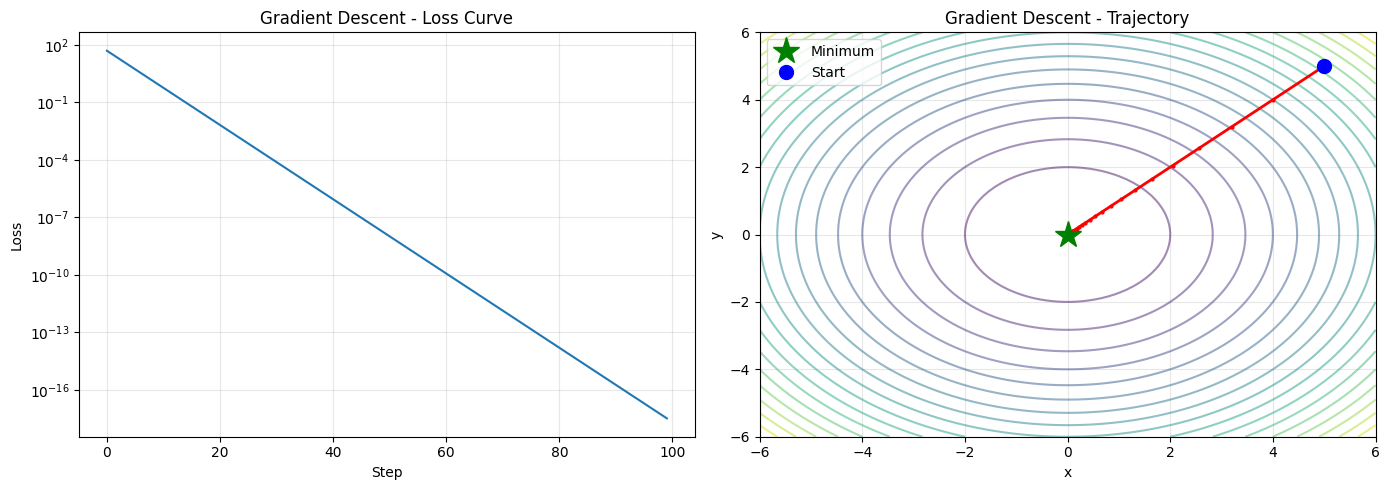

Gradient Descent - Final loss: 0.000000
Final params: [0.000000, 0.000000]



In [46]:
# Test GD
test_optimizer_quadratic(GradientDescent, "Gradient Descent", learning_rate=0.1)

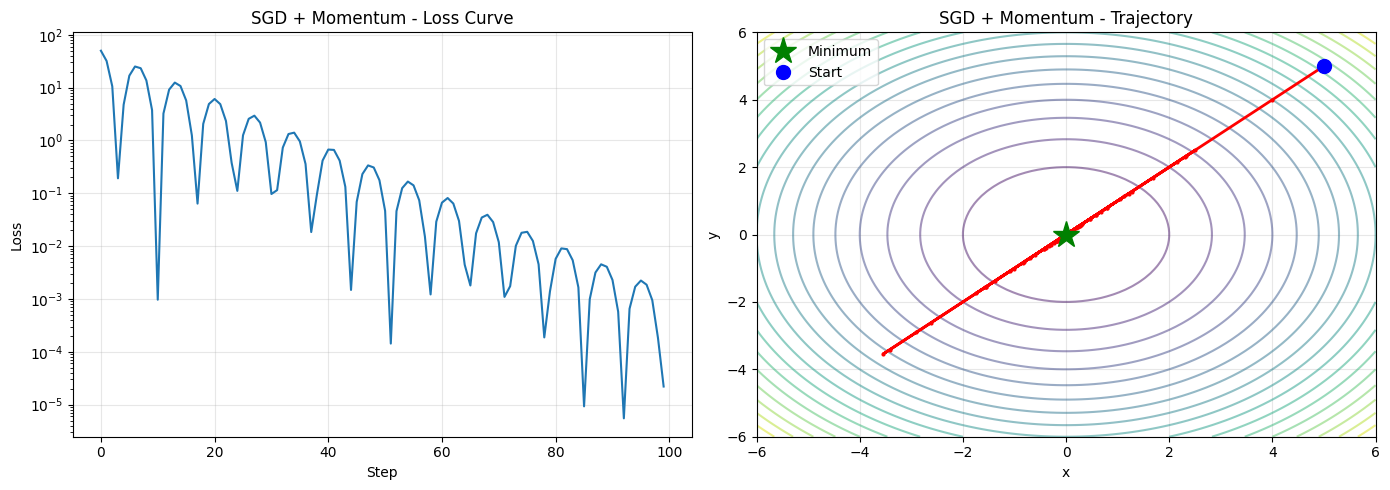

SGD + Momentum - Final loss: 0.000022
Final params: [-0.014257, -0.014257]



In [47]:
# Test SGD with Momentum
test_optimizer_quadratic(SGDMomentum, "SGD + Momentum", learning_rate=0.1, beta=0.9)

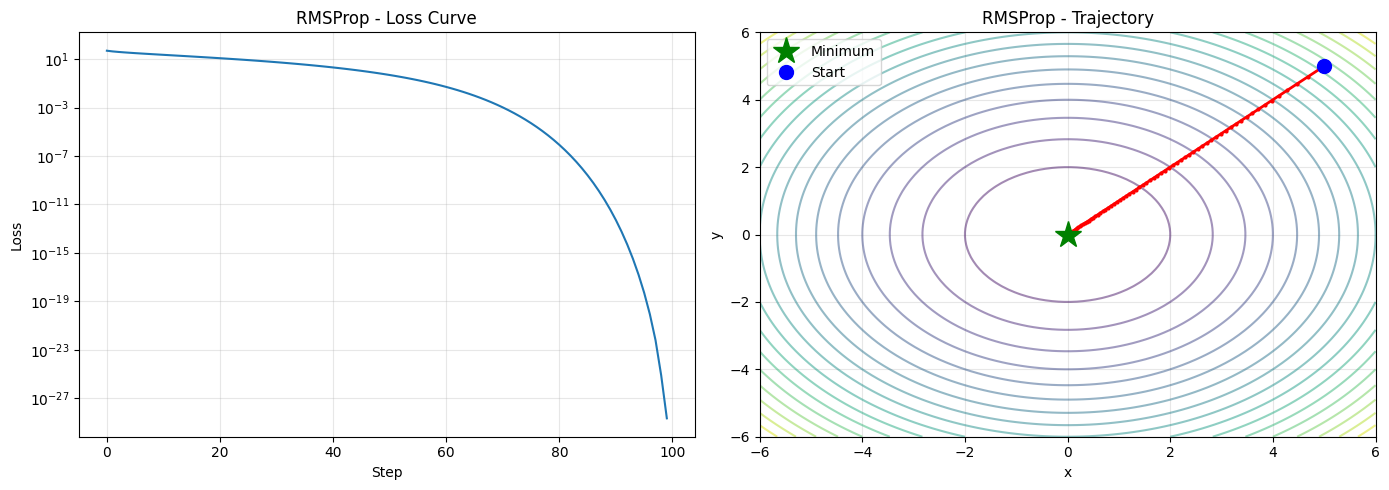

RMSProp - Final loss: 0.000000
Final params: [0.000000, 0.000000]



In [48]:
# Test RMSProp
test_optimizer_quadratic(RMSProp, "RMSProp", learning_rate=0.1, beta=0.9)

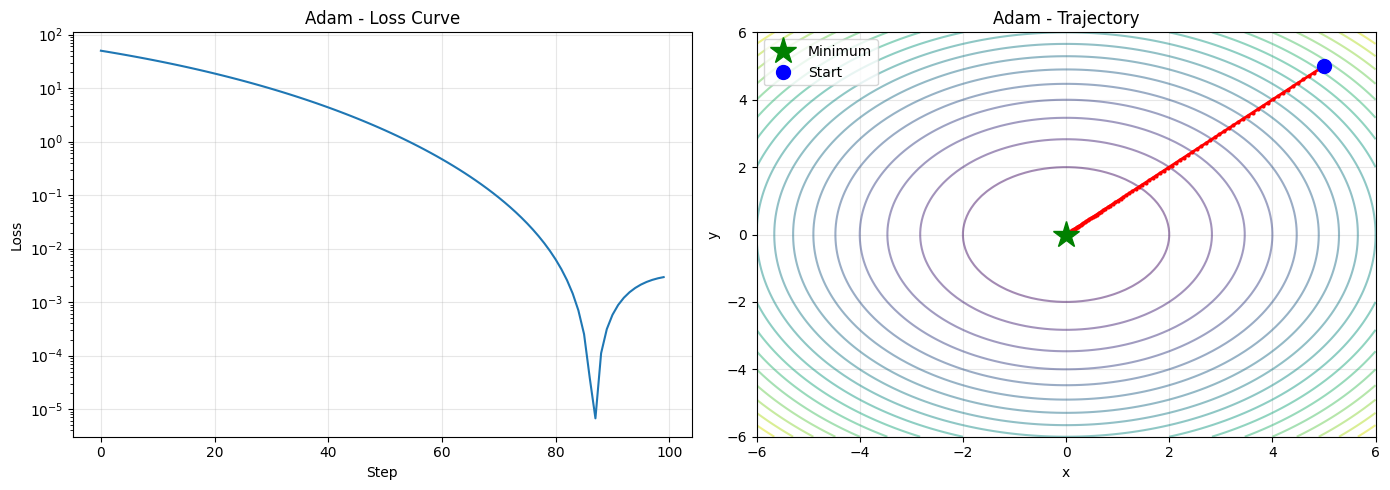

Adam - Final loss: 0.002937
Final params: [-0.039004, -0.039004]



In [49]:
# Test Adam
test_optimizer_quadratic(Adam, "Adam", learning_rate=0.1)

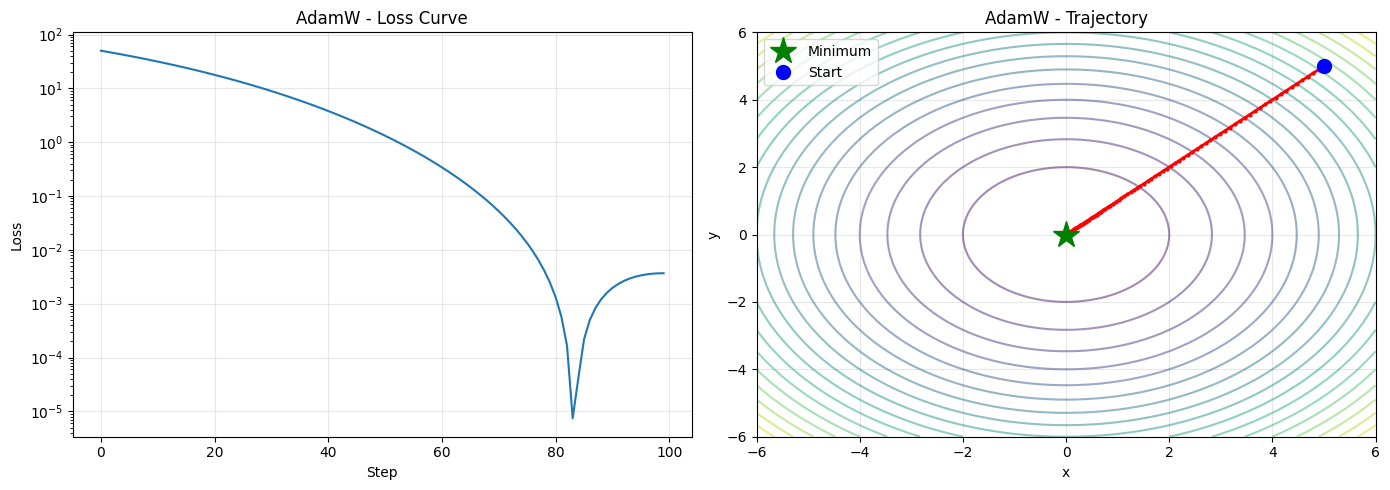

AdamW - Final loss: 0.003679
Final params: [-0.042764, -0.042764]



In [50]:
# Test AdamW
test_optimizer_quadratic(AdamW, "AdamW", learning_rate=0.1, weight_decay=0.01)

---

## Test Problem 2: Rosenbrock Function (Hard)

Minimize the Rosenbrock function (a classic optimization challenge):

`f(x, y) = (1 - x)² + 100(y - x²)²`

- **Global minimum:** `(1, 1)`
- **Initial point:** `(-1, 1)`
- **Challenge:** Narrow valley that's hard to navigate

In [51]:
def rosenbrock_loss(params: np.ndarray) -> float:
    """Rosenbrock function: f(x,y) = (1-x)² + 100(y-x²)²"""
    x, y = params
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(params: np.ndarray) -> np.ndarray:
    """Gradient of Rosenbrock function"""
    x, y = params
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

def test_optimizer_rosenbrock(optimizer_class, optimizer_name: str, **kwargs):
    """Test optimizer on Rosenbrock function"""
    params = np.array([-1.0, 1.0])
    optimizer = optimizer_class(**kwargs)
    
    losses = []
    trajectory = [params.copy()]
    
    for step in range(1000):
        loss = rosenbrock_loss(params)
        losses.append(loss)
        
        grads = rosenbrock_grad(params)
        params = optimizer.step(params, grads)
        trajectory.append(params.copy())
    
    trajectory = np.array(trajectory)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(losses)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{optimizer_name} - Rosenbrock Loss')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    
    # Contour plot
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = (1 - X)**2 + 100 * (Y - X**2)**2
    
    ax2.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), alpha=0.5)
    ax2.plot(trajectory[:, 0], trajectory[:, 1], 'r.-', linewidth=1, markersize=2)
    ax2.plot(1, 1, 'g*', markersize=20, label='Minimum (1, 1)')
    ax2.plot(trajectory[0, 0], trajectory[0, 1], 'bo', markersize=10, label='Start')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title(f'{optimizer_name} - Trajectory')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"{optimizer_name} - Final loss: {losses[-1]:.6f}")
    print(f"Final params: [{params[0]:.6f}, {params[1]:.6f}]")
    print(f"Distance to minimum: {np.linalg.norm(params - np.array([1.0, 1.0])):.6f}\n")

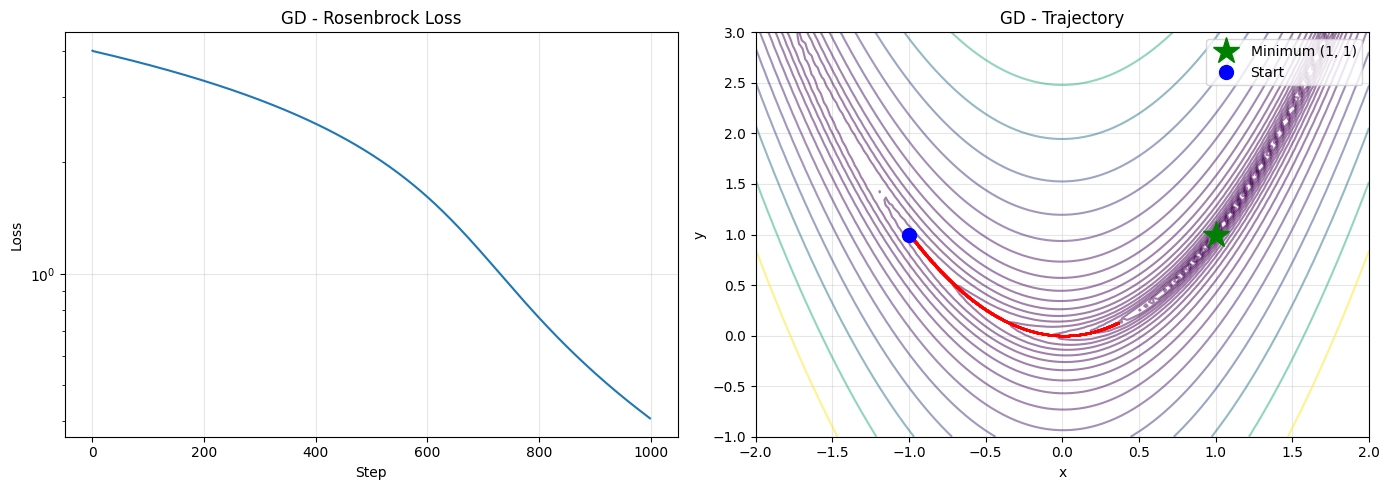

GD - Final loss: 0.406938
Final params: [0.363640, 0.129199]
Distance to minimum: 1.078540



In [52]:
# Test all optimizers on Rosenbrock
test_optimizer_rosenbrock(GradientDescent, "GD", learning_rate=0.001)

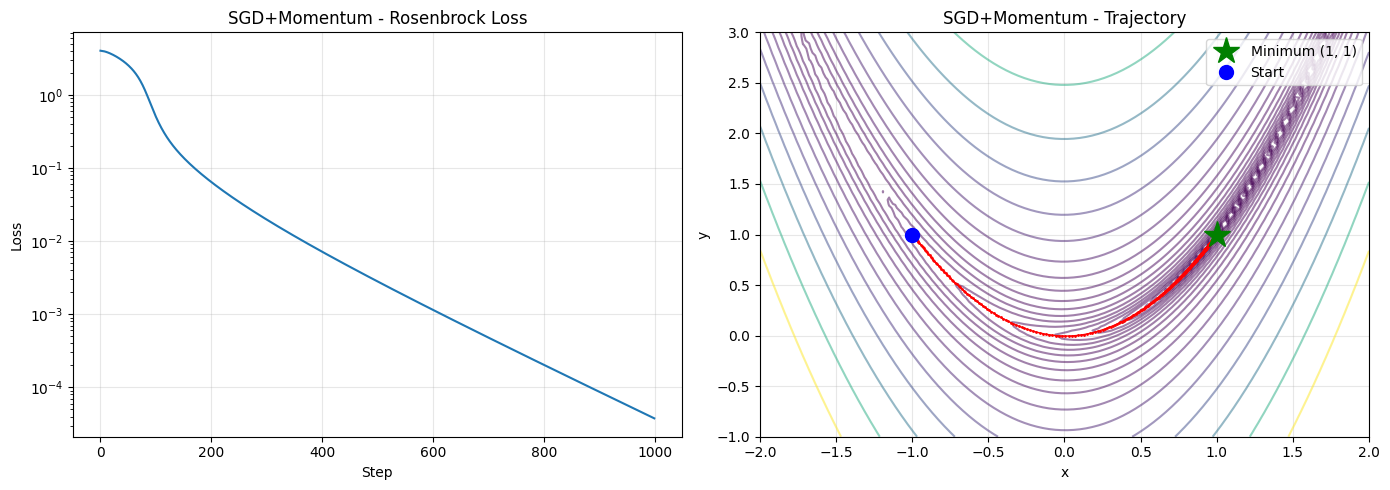

SGD+Momentum - Final loss: 0.000038
Final params: [0.993886, 0.987785]
Distance to minimum: 0.013660



In [53]:
test_optimizer_rosenbrock(SGDMomentum, "SGD+Momentum", learning_rate=0.001, beta=0.9)

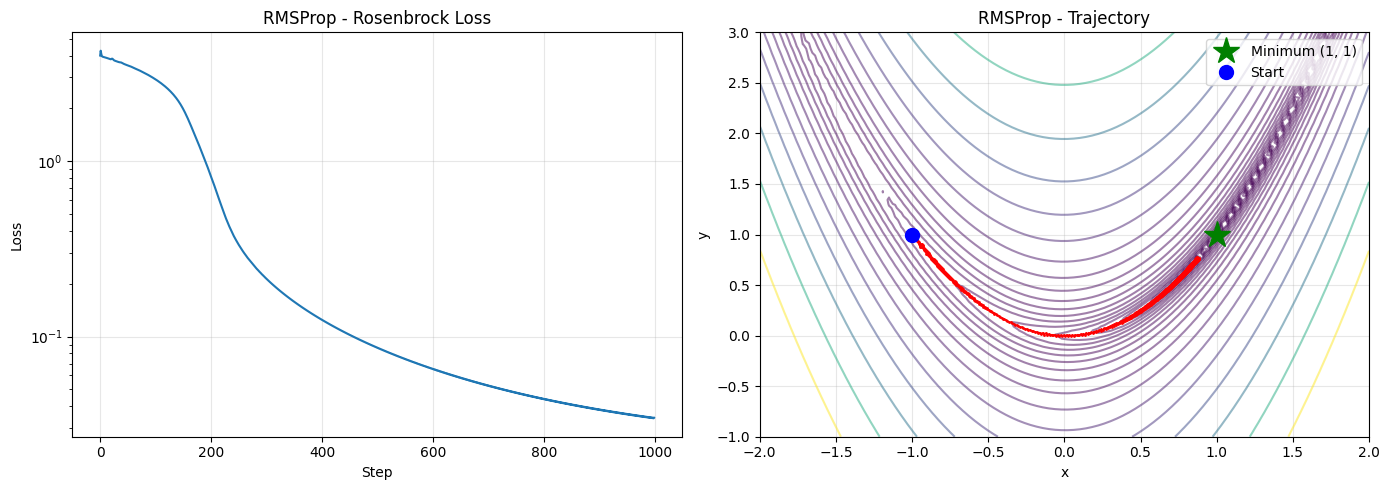

RMSProp - Final loss: 0.034389
Final params: [0.881932, 0.763613]
Distance to minimum: 0.264232



In [54]:
test_optimizer_rosenbrock(RMSProp, "RMSProp", learning_rate=0.01, beta=0.9)

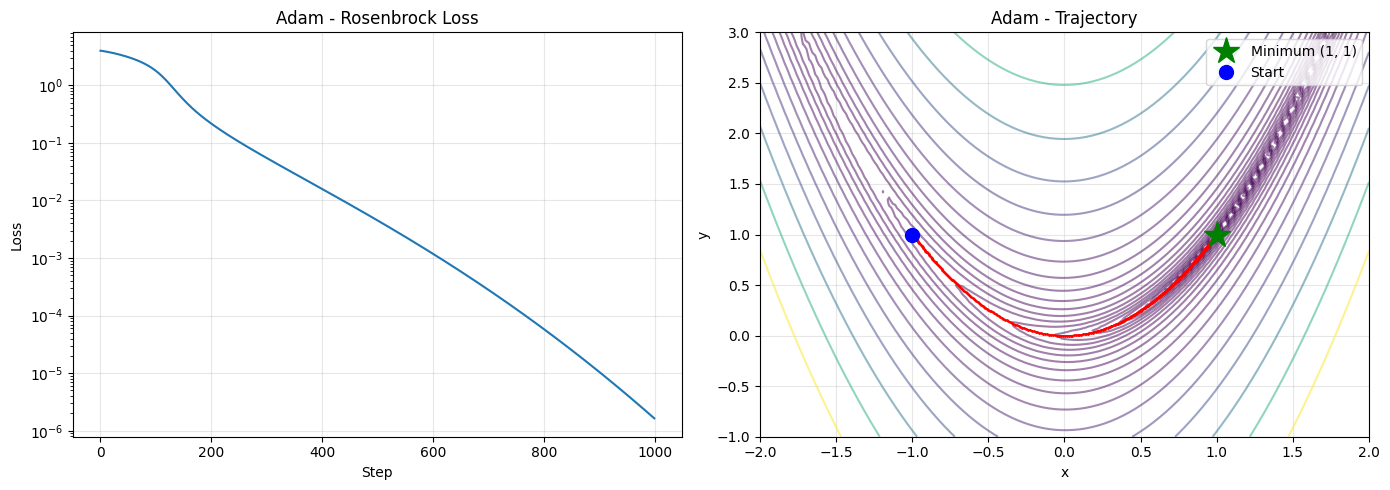

Adam - Final loss: 0.000002
Final params: [0.998732, 0.997461]
Distance to minimum: 0.002838



In [55]:
test_optimizer_rosenbrock(Adam, "Adam", learning_rate=0.01)

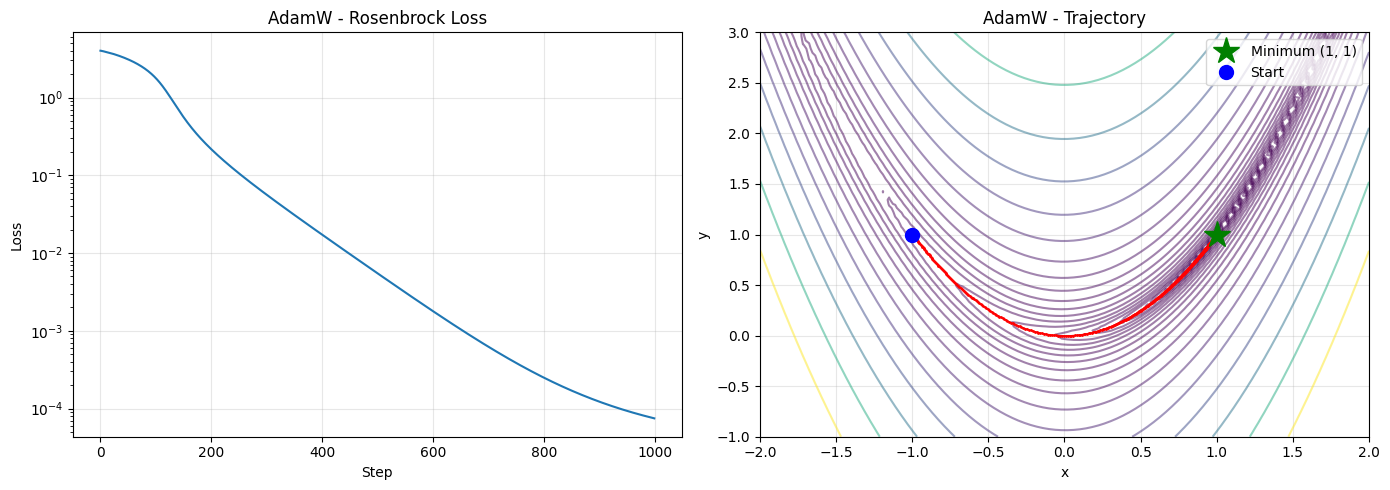

AdamW - Final loss: 0.000075
Final params: [0.991368, 0.982782]
Distance to minimum: 0.019261



In [56]:
test_optimizer_rosenbrock(AdamW, "AdamW", learning_rate=0.01, weight_decay=0.01)

---

## Analysis Questions (Answer in markdown)

After running the tests, answer the following:

### Q1: Convergence Speed
Which optimizer converged fastest on:
- Quadratic function?
- Rosenbrock function?

Why do you think this is the case?

**Your answer:**

- **Quadratic:** GD and RMSProp both converged to exact zero loss. The quadratic is a simple, symmetric, convex function — no complex curvature to navigate, so plain GD with a good learning rate is already optimal. Adaptive methods like Adam actually overshoot and oscillate near the minimum.
- **Rosenbrock:** Adam converged fastest (loss = 0.000002, distance = 0.0028). The Rosenbrock function has a narrow curved valley with very different curvatures along x and y. Adam combines momentum (to move along the valley) with per-parameter adaptive learning rates (to handle the curvature difference), making it well-suited for this landscape.


### Q2: Momentum Effect
Compare vanilla GD vs SGD+Momentum. What difference do you observe in the trajectory? Why does momentum help?

**Your answer:**

- On the **quadratic**, GD follows a clean straight-line path to the minimum, while SGD+Momentum oscillates slightly because accumulated velocity causes it to overshoot.
- On **Rosenbrock**, momentum makes a huge difference — GD barely moves (final loss 0.41) while SGD+Momentum reaches near the minimum (loss 0.00004). Momentum helps because it accumulates gradient information over time, building up speed along the consistent direction of the valley while oscillations perpendicular to the valley cancel out. Like a ball rolling downhill — it picks up speed in the dominant direction.


### Q3: Adaptive Learning Rates
How do RMSProp and Adam handle the Rosenbrock valley differently than GD? Why?

**Your answer:**

GD uses the same learning rate for all parameters, so in the Rosenbrock valley where the gradient is much steeper in one direction than the other, it either moves too slowly along the valley floor or overshoots perpendicular to it.

RMSProp and Adam maintain per-parameter learning rates by dividing by the square root of the running average of squared gradients. Parameters with large gradients get smaller effective learning rates, and parameters with small gradients get larger ones. This allows them to take appropriately-sized steps in each direction — larger steps along the flat valley floor and smaller steps across the steep walls. Adam additionally benefits from momentum, which is why it outperforms RMSProp (loss 0.000002 vs 0.034).


### Q4: Adam vs AdamW
Did you notice any difference between Adam and AdamW on these test problems? Why or why not?

**Your answer:**

The difference is small but present. On the quadratic, AdamW (loss 0.0037) performed slightly worse than Adam (loss 0.0029). On Rosenbrock, Adam (loss 0.000002) also beat AdamW (loss 0.000075).

This is expected because the weight decay term in AdamW pushes parameters toward zero, which hurts here — the Rosenbrock minimum is at (1, 1), not (0, 0). On these simple test problems without overfitting risk, the weight decay is purely a penalty. The real benefit of AdamW shows up in training deep neural networks, where decoupled weight decay provides better generalization than L2 regularization baked into the gradients.


### Q5: Hyperparameter Sensitivity
Try changing the learning rate for GD and Adam. Which one is more sensitive to learning rate choice?

**Your answer:**

**GD is more sensitive to learning rate.** With GD on Rosenbrock:
- lr=0.001: loss = 0.41 (barely converges)
- lr=0.01: would diverge due to steep gradients

Adam is more robust because its adaptive learning rates automatically scale the effective step size. Even with lr=0.1 or lr=0.001, Adam adjusts per-parameter rates based on gradient history. GD has no such mechanism — too small and it converges painfully slowly, too large and it diverges. This robustness to hyperparameter choice is one of the main reasons Adam is so popular in practice.

---

## Bonus: Compare All Optimizers (10 bonus points)

Create a single plot comparing all 5 optimizers on the same problem.

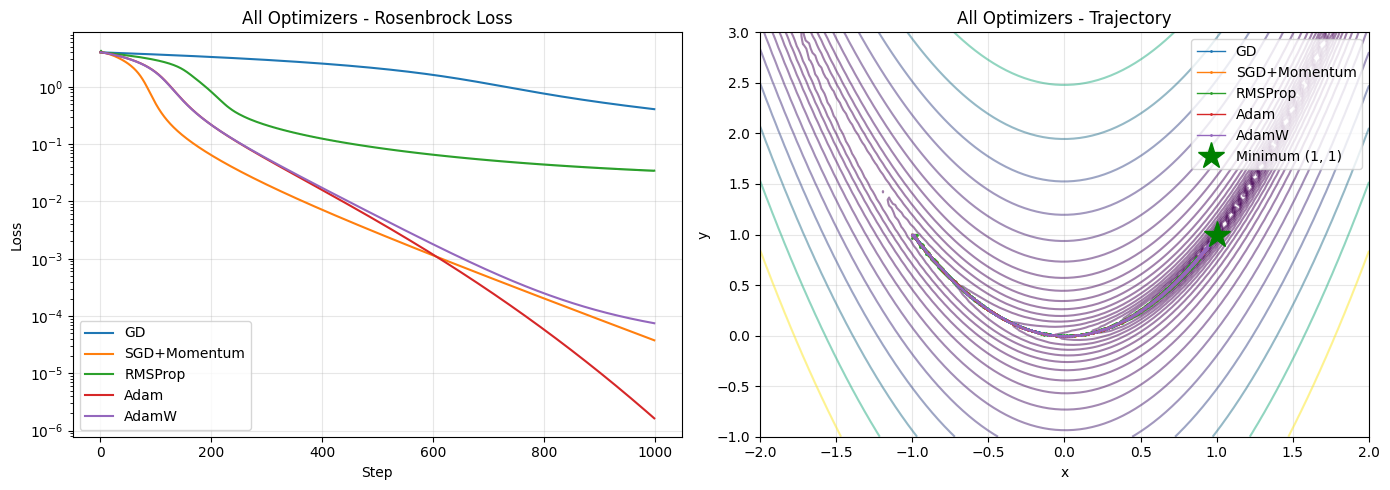

In [62]:
def compare_all_optimizers():
    optimizers = [
        ("GD", GradientDescent, {"learning_rate": 0.001}),
        ("SGD+Momentum", SGDMomentum, {"learning_rate": 0.001, "beta": 0.9}),
        ("RMSProp", RMSProp, {"learning_rate": 0.01, "beta": 0.9}),
        ("Adam", Adam, {"learning_rate": 0.01}),
        ("AdamW", AdamW, {"learning_rate": 0.01, "weight_decay": 0.01}),
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    x = np.linspace(-2, 2, 100)
    y = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = (1 - X)**2 + 100 * (Y - X**2)**2
    ax2.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), alpha=0.5)

    for name, opt_class, kwargs in optimizers:
        params = np.array([-1.0, 1.0])
        optimizer = opt_class(**kwargs)
        losses = []
        trajectory = [params.copy()]

        for step in range(1000):
            loss = rosenbrock_loss(params)
            losses.append(loss)
            grads = rosenbrock_grad(params)
            params = optimizer.step(params, grads)
            trajectory.append(params.copy())

        trajectory = np.array(trajectory)
        ax1.plot(losses, label=name)
        ax2.plot(trajectory[:, 0], trajectory[:, 1], '.-', linewidth=1, markersize=2, label=name)

    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.set_title('All Optimizers - Rosenbrock Loss')
    ax1.set_yscale('log')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(1, 1, 'g*', markersize=20, label='Minimum (1, 1)')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('All Optimizers - Trajectory')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

compare_all_optimizers()


---

## Grading Rubric

| Problem | Points | Criteria |
|---------|--------|----------|
| GD | 10 | Correct implementation, passes quadratic test |
| SGD+Momentum | 15 | Correct velocity update, initialization |
| RMSProp | 20 | Correct moving average, adaptive LR |
| Adam | 25 | Correct bias correction, both moments |
| AdamW | 30 | Correct decoupled weight decay |
| Bonus | 10 | Clean comparison visualization |
| **Total** | **100 (+10)** | |

**Submission:**
- Complete notebook with all implementations
- All test outputs visible
- Analysis questions answered
- Code should be clean and commented

**Academic Integrity:**
- Implement from scratch (no sklearn, torch.optim, etc.)
- You may reference formulas from papers/blogs
- Cite any external resources used